# 10. Labour-Implied GDP From Unemployment and Employment

This notebook inverts the time-varying labour-market equations to recover the GDP growth path implied by observed unemployment changes and by observed employment growth. The benchmark `Y -> U` and `Y -> E` measurement equations are taken as given, while GDP growth follows a separately estimated AR(2) law of motion with pandemic pulse dummies included only in the AR estimation step.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.append(str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from swiss_labour_break_even.inverse_filtering import InverseGDPConfig, filter_implied_gdp

plt.style.use('seaborn-v0_8-whitegrid')
DATA_PATH = PROJECT_ROOT / 'data' / 'prepared' / 'analysis_dataset_quarterly.csv'
OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'implied_gdp_from_labour_market.csv'

## Run the Two Inverse Filters

In [2]:
analysis_df = pd.read_csv(DATA_PATH, parse_dates=['date'])

u_config = InverseGDPConfig(eta_ratio=0.05, observable_col='U')
e_config = InverseGDPConfig(eta_ratio=0.05, observable_col='E')

u_implied_df, u_ols_result, u_measurement_result, u_ar2_result = filter_implied_gdp(analysis_df, config=u_config)
e_implied_df, e_ols_result, e_measurement_result, e_ar2_result = filter_implied_gdp(analysis_df, config=e_config)

combined = u_implied_df[['date', 'Y', 'gdp_implied_smoothed', 'gdp_implied_annualized_pct', 'gdp_actual_annualized_pct']].rename(columns={
    'gdp_implied_smoothed': 'gdp_u_implied_smoothed',
    'gdp_implied_annualized_pct': 'gdp_u_implied_annualized_pct',
})
combined = combined.merge(
    e_implied_df[['date', 'gdp_implied_smoothed', 'gdp_implied_annualized_pct']].rename(columns={
        'gdp_implied_smoothed': 'gdp_e_implied_smoothed',
        'gdp_implied_annualized_pct': 'gdp_e_implied_annualized_pct',
    }),
    on='date',
    how='inner',
)
combined.to_csv(OUTPUT_PATH, index=False)
combined.tail()

,date,Y,gdp_u_implied_smoothed,gdp_u_implied_annualized_pct,gdp_actual_annualized_pct,gdp_e_implied_smoothed,gdp_e_implied_annualized_pct
129,2024-10-01,0.470373,0.212774,0.853814,1.894809,0.253287,1.017005
130,2025-01-01,0.879817,0.168448,0.675495,3.565988,0.124640,0.499493
131,2025-04-01,0.150667,0.210713,0.845520,0.604033,-0.020872,-0.083461
132,2025-07-01,-0.414915,0.329533,1.324661,-1.649358,0.075624,0.302840
133,2025-10-01,0.226345,0.419975,1.690510,0.908460,0.245083,0.983942


## Measurement Equations and GDP AR(2) Laws

In [3]:
summary_table = pd.DataFrame({
    'model': ['U-implied GDP', 'E-implied GDP'],
    'beta_Y': [u_measurement_result.params['beta.Y'], e_measurement_result.params['beta.Y']],
    'beta_Y_lag1': [u_measurement_result.params['beta.Y_lag1'], e_measurement_result.params['beta.Y_lag1']],
    'beta_Y_lag2': [u_measurement_result.params['beta.Y_lag2'], e_measurement_result.params['beta.Y_lag2']],
    'sigma_eps': [np.sqrt(u_measurement_result.params['sigma2.irregular']), np.sqrt(e_measurement_result.params['sigma2.irregular'])],
    'sigma_eta_fixed': [np.sqrt(u_measurement_result.params['sigma2.level']), np.sqrt(e_measurement_result.params['sigma2.level'])],
    'ar_const': [u_ar2_result.params['const'], e_ar2_result.params['const']],
    'ar_lag1': [u_ar2_result.params['Y_lag1'], e_ar2_result.params['Y_lag1']],
    'ar_lag2': [u_ar2_result.params['Y_lag2'], e_ar2_result.params['Y_lag2']],
    'ar_d2020q2': [u_ar2_result.params['d2020q2'], e_ar2_result.params['d2020q2']],
    'ar_d2020q3': [u_ar2_result.params['d2020q3'], e_ar2_result.params['d2020q3']],
})
summary_table

,model,beta_Y,beta_Y_lag1,beta_Y_lag2,sigma_eps,sigma_eta_fixed,ar_const,ar_lag1,ar_lag2,ar_d2020q2,ar_d2020q3
0,U-implied GDP,-0.086437,-0.109001,-0.073952,0.14885,0.007876,0.277121,0.280703,0.060707,-6.353016,7.656081
1,E-implied GDP,0.202436,0.119011,0.034753,0.28504,0.015988,0.277121,0.280703,0.060707,-6.353016,7.656081


In [4]:
print('AR(2) for GDP used in the U-implied inversion')
print(u_ar2_result.summary())

AR(2) for GDP used in the U-implied inversion
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.652
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     60.31
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           1.26e-28
Time:                        09:59:36   Log-Likelihood:                -117.20
No. Observations:                 134   AIC:                             244.4
Df Residuals:                     129   BIC:                             258.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

In [5]:
print('AR(2) for GDP used in the E-implied inversion')
print(e_ar2_result.summary())

AR(2) for GDP used in the E-implied inversion
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.652
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     60.31
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           1.26e-28
Time:                        09:59:36   Log-Likelihood:                -117.20
No. Observations:                 134   AIC:                             244.4
Df Residuals:                     129   BIC:                             258.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

## Compare Actual and Labour-Implied GDP Growth

In [6]:
comparison_stats = pd.DataFrame({
    'metric': ['Correlation with actual Y', 'RMSE vs actual Y', 'Mean implied Y'],
    'U-implied': [
        combined['Y'].corr(combined['gdp_u_implied_smoothed']),
        np.sqrt(np.mean((combined['gdp_u_implied_smoothed'] - combined['Y']) ** 2)),
        combined['gdp_u_implied_smoothed'].mean(),
    ],
    'E-implied': [
        combined['Y'].corr(combined['gdp_e_implied_smoothed']),
        np.sqrt(np.mean((combined['gdp_e_implied_smoothed'] - combined['Y']) ** 2)),
        combined['gdp_e_implied_smoothed'].mean(),
    ],
})
comparison_stats

,metric,U-implied,E-implied
0,Correlation with actual Y,0.447948,0.493988
1,RMSE vs actual Y,0.881430,0.860618
2,Mean implied Y,0.439622,0.435368


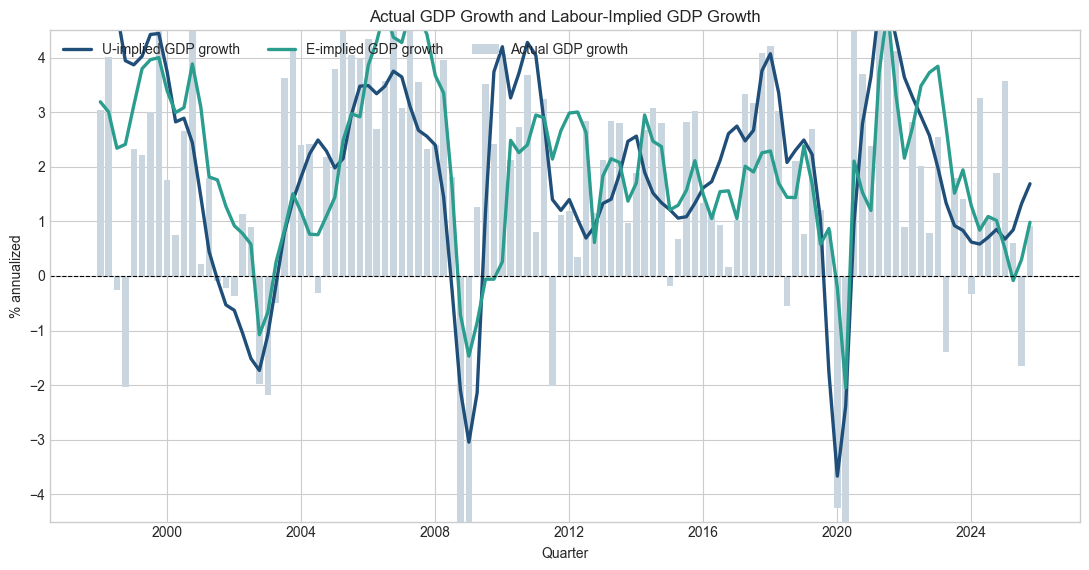

In [7]:
plot_df = combined[combined['date'] >= '1998-01-01'].copy()
fig, ax = plt.subplots(figsize=(11, 5.8))

bar_width_days = 70
ax.bar(plot_df['date'], plot_df['gdp_actual_annualized_pct'], width=bar_width_days, color='#c9d6df', edgecolor='none', label='Actual GDP growth')
ax.plot(plot_df['date'], plot_df['gdp_u_implied_annualized_pct'], linewidth=2.4, color='#1f4e79', label='U-implied GDP growth')
ax.plot(plot_df['date'], plot_df['gdp_e_implied_annualized_pct'], linewidth=2.4, color='#2a9d8f', label='E-implied GDP growth')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Actual GDP Growth and Labour-Implied GDP Growth')
ax.set_ylabel('% annualized')
ax.set_xlabel('Quarter')
ax.set_ylim(-4.5, 4.5)
ax.legend(frameon=False, ncol=3, loc='upper left')
fig.tight_layout()
plt.show()

In [8]:
latest = combined.iloc[-1]
latest_table = pd.DataFrame({
    'item': [
        'Latest actual GDP growth (q/q)',
        'Latest U-implied GDP growth (q/q)',
        'Latest E-implied GDP growth (q/q)',
        'Latest actual GDP growth (annualized)',
        'Latest U-implied GDP growth (annualized)',
        'Latest E-implied GDP growth (annualized)',
    ],
    'value': [
        latest['Y'],
        latest['gdp_u_implied_smoothed'],
        latest['gdp_e_implied_smoothed'],
        latest['gdp_actual_annualized_pct'],
        latest['gdp_u_implied_annualized_pct'],
        latest['gdp_e_implied_annualized_pct'],
    ],
})
latest_table

,item,value
0,Latest actual GDP growth (q/q),0.226345
1,Latest U-implied GDP growth (q/q),0.419975
2,Latest E-implied GDP growth (q/q),0.245083
3,Latest actual GDP growth (annualized),0.908460
4,Latest U-implied GDP growth (annualized),1.690510
5,Latest E-implied GDP growth (annualized),0.983942


## Interpretation

This is an inverse-model exercise. The two implied GDP lines answer the question: conditional on the labour-market equations and a separate AR(2) law of motion for GDP, what GDP growth path is most consistent with the observed unemployment path and with the observed employment path? The purpose is diagnostic and interpretive, not to replace the official GDP data.